# CareAssist EDA - Foster Care Data Analysis
## Initial Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

In [2]:
# Creating dataframes for each year. 2019 is different as it is separated by tabs.
data_2019 = pd.read_csv('/content/FC2019ABv1.csv', sep='\t', low_memory=False)
data_2020 = pd.read_csv('/content/FC2020ABv1.csv', low_memory=False)
data_2021 = pd.read_csv('/content/FC2021ABv1.csv', low_memory=False)
data_2022 = pd.read_csv('/content/FC2022ABv1.csv', low_memory=False)
data_2023 = pd.read_csv('/content/FC2023ABv1.csv', low_memory=False)
data_2024 = pd.read_csv('/content/FC2024ABv1.csv', low_memory=False)

In [31]:
dataframes_list = [data_2019, data_2020, data_2021, data_2022, data_2023, data_2024]

# Tag each row with its source year before combining
for year, df in zip(range(2019, 2025), dataframes_list):
    df['source_year'] = year

combined_data = pd.concat(dataframes_list, ignore_index=True)
print(f"Combined DataFrame shape before deduplication: {combined_data.shape}")

# Keep one record per child per year (stfcid + source_year).
# This preserves a child's full history across years while removing
# true duplicates within a single year's file.
combined_data = (
    combined_data
    .drop_duplicates(subset=['stfcid', 'source_year'], keep='first')
    .reset_index(drop=True)
)

print(f"Combined DataFrame shape after deduplication: {combined_data.shape}")
print(f"Unique children (stfcid): {combined_data['stfcid'].nunique():,}")
print(f"Unique child-year records: {combined_data[['stfcid', 'source_year']].drop_duplicates().shape[0]:,}")
print(combined_data.head())

# Save the combined DataFrame to a CSV file
# combined_data.to_csv('/content/combined_data.csv', index=False)
# print("Combined DataFrame saved to /content/combined_data.csv")

Combined DataFrame shape before deduplication: (3556631, 105)
Combined DataFrame shape after deduplication: (3556631, 105)
Unique children (stfcid): 1,542,888
Unique child-year records: 3,556,631
     fy  version  state  st  repdatyr  repdatmo  fipscode      recnumbr  sex  \
0  2019        1     28  MS      2019         9         8  ›‡†œ‡5š1‹1ˆŸ  1.0   
1  2019        1     28  MS      2019         9         8  ›‡†œ‡5š1‹1Œ—  1.0   
2  2019        1     28  MS      2019         9     28047  ›‡†œ‡5š1ˆƒ2–  1.0   
3  2019        1     28  MS      2019         9         8  ›‡†œ‡5š12„ˆ–  2.0   
4  2019        1     28  MS      2019         9         8  ›‡†œ‡5š1ƒ„Œ4  1.0   

   amiakn  asian  blkafram  hawaiipi  white  untodetm  hisorgin  clindis   mr  \
0     0.0    0.0       1.0       0.0    0.0       0.0       2.0      2.0  0.0   
1     0.0    0.0       1.0       0.0    0.0       0.0       2.0      2.0  0.0   
2     0.0    0.0       0.0       0.0    1.0       0.0       2.0      2.0  0.0   

## Combine DataFrames

In [4]:
dataframes_list = [data_2019, data_2020, data_2021, data_2022, data_2023, data_2024]
combined_data = pd.concat(dataframes_list, ignore_index=True)
print(f"Combined DataFrame shape: {combined_data.shape}")
print(combined_data.head())

# Save the combined DataFrame to a CSV file
# combined_data.to_csv('/content/combined_data.csv', index=False)
# print("Combined DataFrame saved to /content/combined_data.csv")

Combined DataFrame shape: (3556631, 104)
     fy  version  state  st  repdatyr  repdatmo  fipscode      recnumbr  sex  \
0  2019        1     28  MS      2019         9         8  ›‡†œ‡5š1‹1ˆŸ  1.0   
1  2019        1     28  MS      2019         9         8  ›‡†œ‡5š1‹1Œ—  1.0   
2  2019        1     28  MS      2019         9     28047  ›‡†œ‡5š1ˆƒ2–  1.0   
3  2019        1     28  MS      2019         9         8  ›‡†œ‡5š12„ˆ–  2.0   
4  2019        1     28  MS      2019         9         8  ›‡†œ‡5š1ƒ„Œ4  1.0   

   amiakn  asian  blkafram  hawaiipi  white  untodetm  hisorgin  clindis   mr  \
0     0.0    0.0       1.0       0.0    0.0       0.0       2.0      2.0  0.0   
1     0.0    0.0       1.0       0.0    0.0       0.0       2.0      2.0  0.0   
2     0.0    0.0       0.0       0.0    1.0       0.0       2.0      2.0  0.0   
3     0.0    0.0       0.0       0.0    1.0       0.0       2.0      2.0  0.0   
4     0.0    0.0       0.0       0.0    1.0       0.0       2.0      2.0 

In [5]:
print("Overall lifelos percentiles:\n", combined_data['lifelos'].quantile([0.5, 0.75, 0.9]))
print("Overall totalrem percentiles:\n", combined_data['totalrem'].quantile([0.5, 0.75, 0.9]))
print("Overall numplep percentiles:\n", combined_data['numplep'].quantile([0.5, 0.75, 0.9]))

Overall lifelos percentiles:
 0.50     534.0
0.75     975.0
0.90    1586.0
Name: lifelos, dtype: float64
Overall totalrem percentiles:
 0.50    1.0
0.75    1.0
0.90    2.0
Name: totalrem, dtype: float64
Overall numplep percentiles:
 0.50    2.0
0.75    3.0
0.90    6.0
Name: numplep, dtype: float64


# STEP 1: Separate Data by Age Ranges
## Using AgeAtLatRem (Age at Most Recent Removal)

**Rationale**: Using AgeAtLatRem makes more theoretical sense because:
- It reflects the child's developmental stage at the time they entered care
- Removal reasons, instability, and permanency processes are tied to entry circumstances
- AgeAtStart could misclassify children who crossed a birthday by October 1
- Entry age is more predictive of outcomes and service needs

In [6]:
# Define age groups based on AgeAtLatRem
def categorize_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <= 2:
        return '0-2'
    elif age <= 5:
        return '3-5'
    elif age <= 9:
        return '6-9'
    elif age <= 13:
        return '10-13'
    elif age <= 17:
        return '14-17'
    else:
        return '18+'

combined_data['age_group'] = combined_data['ageatlatrem'].apply(categorize_age)

# Display distribution
print("\nAge Group Distribution:")
print(combined_data['age_group'].value_counts().sort_index())
print(f"\nPercentage Distribution:")
print(combined_data['age_group'].value_counts(normalize=True).sort_index() * 100)


Age Group Distribution:
age_group
0-2      1183116
10-13     596690
14-17     522620
18+        38317
3-5       576447
6-9       639441
Name: count, dtype: int64

Percentage Distribution:
age_group
0-2      33.265076
10-13    16.776832
14-17    14.694243
18+       1.077340
3-5      16.207670
6-9      17.978840
Name: proportion, dtype: float64


In [30]:
# Create separate dataframes for each age group
age_0_2 = combined_data[combined_data['age_group'] == '0-2'].copy()
age_3_5 = combined_data[combined_data['age_group'] == '3-5'].copy()
age_6_9 = combined_data[combined_data['age_group'] == '6-9'].copy()
age_10_13 = combined_data[combined_data['age_group'] == '10-13'].copy()
age_14_17 = combined_data[combined_data['age_group'] == '14-17'].copy()
age_18_plus = combined_data[combined_data['age_group'] == '18+'].copy()

print(f"Age 0-2: {len(age_0_2):,} records")
print(f"Age 3-5: {len(age_3_5):,} records")
print(f"Age 6-9: {len(age_6_9):,} records")
print(f"Age 10-13: {len(age_10_13):,} records")
print(f"Age 14-17: {len(age_14_17):,} records")
print(f"Age 18+: {len(age_18_plus):,} records")

Age 0-2: 1,183,116 records
Age 3-5: 576,447 records
Age 6-9: 639,441 records
Age 10-13: 596,690 records
Age 14-17: 522,620 records
Age 18+: 38,317 records


# STEP 2: Missing Values Analysis
## Analyze NULL/Missing Values for Key Variables

In [8]:
# Define all variables of interest across domains
domain_variables = {
    'Placement Instability': ['totalrem', 'numplep', 'lifelos', 'latremlos'],
    'Safety & Removal Context': ['phyabuse', 'sexabuse', 'neglect', 'darem', 'daparent',
                                   'aarem', 'aaparent', 'dachild', 'aachild', 'abandmnt',
                                   'nocope', 'prtsjail', 'housing'],
    'Health & Special Needs': ['clindis', 'emotdist', 'phydis', 'mr', 'vishear', 'othermed'],
    'Legal & Permanency': ['prtsdied', 'istpr', 'iswaiting', 'relinqsh'],
    'Age-Related': ['ageatlatrem', 'agedout'],
    'Current Placement': ['disreasn']
}

# Flatten the list of all variables
all_variables = [var for vars_list in domain_variables.values() for var in vars_list]

# Check which variables exist in the dataset
existing_vars = [var for var in all_variables if var in combined_data.columns]
missing_vars = [var for var in all_variables if var not in combined_data.columns]

print("Variables found in dataset:")
print(existing_vars)
print(f"\nVariables NOT found in dataset:")
print(missing_vars)

Variables found in dataset:
['totalrem', 'numplep', 'lifelos', 'latremlos', 'phyabuse', 'sexabuse', 'neglect', 'daparent', 'aaparent', 'dachild', 'aachild', 'abandmnt', 'nocope', 'prtsjail', 'housing', 'clindis', 'emotdist', 'phydis', 'mr', 'vishear', 'othermed', 'prtsdied', 'istpr', 'iswaiting', 'relinqsh', 'ageatlatrem', 'agedout', 'disreasn']

Variables NOT found in dataset:
['darem', 'aarem']


In [9]:
# Create comprehensive missing value report
def missing_values_analysis(df, variables, title="Missing Values Analysis"):
    print(f"\n{'='*80}")
    print(f"{title}")
    print(f"{'='*80}")

    missing_data = []
    for var in variables:
        if var in df.columns:
            total = len(df)
            missing = df[var].isna().sum()
            pct = (missing / total) * 100
            missing_data.append({
                'Variable': var,
                'Missing Count': missing,
                'Total Count': total,
                'Missing %': round(pct, 2),
                'Present Count': total - missing
            })

    missing_df = pd.DataFrame(missing_data)
    missing_df = missing_df.sort_values('Missing %', ascending=False)
    return missing_df

# Overall missing values
overall_missing = missing_values_analysis(combined_data, existing_vars, "Overall Dataset")
print(overall_missing.to_string(index=False))


Overall Dataset
   Variable  Missing Count  Total Count  Missing %  Present Count
   othermed         811865      3556631      22.83        2744766
   emotdist         809600      3556631      22.76        2747031
     phydis         808423      3556631      22.73        2748208
         mr         807875      3556631      22.71        2748756
    vishear         805053      3556631      22.64        2751578
   abandmnt         224616      3556631       6.32        3332015
   prtsjail         219312      3556631       6.17        3337319
     nocope         197104      3556631       5.54        3359527
    lifelos         166645      3556631       4.69        3389986
    clindis         114367      3556631       3.22        3442264
   aaparent          95713      3556631       2.69        3460918
    housing          66904      3556631       1.88        3489727
    neglect          61337      3556631       1.72        3495294
   daparent          44925      3556631       1.26        3

In [10]:
# Special focus on LifeLOS and TotalRem relationship
print("\n" + "="*80)
print("LIFELOS ANALYSIS: Understanding NULL patterns")
print("="*80)

# Analyze TotalRem distribution
print("\nTotalRem Distribution:")
totalrem_dist = combined_data['totalrem'].value_counts().sort_index()
print(totalrem_dist)

print(f"\nCases where TotalRem > 2: {(combined_data['totalrem'] > 2).sum():,}")
print(f"Percentage: {(combined_data['totalrem'] > 2).sum() / len(combined_data) * 100:.2f}%")

print(f"\nCases where TotalRem is NULL: {combined_data['totalrem'].isna().sum():,}")
print(f"Percentage: {combined_data['totalrem'].isna().sum() / len(combined_data) * 100:.2f}%")

# Analyze LifeLOS based on TotalRem
print("\nLifeLOS NULL status by TotalRem:")
for totalrem_val in [1, 2]:
    subset = combined_data[combined_data['totalrem'] == totalrem_val]
    lifelos_null = subset['lifelos'].isna().sum()
    print(f"TotalRem = {totalrem_val}: {lifelos_null:,} NULL LifeLOS ({lifelos_null/len(subset)*100:.2f}%)")

subset_gt2 = combined_data[combined_data['totalrem'] > 2]
lifelos_null_gt2 = subset_gt2['lifelos'].isna().sum()
print(f"TotalRem > 2: {lifelos_null_gt2:,} NULL LifeLOS ({lifelos_null_gt2/len(subset_gt2)*100:.2f}%)")

subset_null_rem = combined_data[combined_data['totalrem'].isna()]
lifelos_null_null_rem = subset_null_rem['lifelos'].isna().sum()
print(f"TotalRem NULL: {lifelos_null_null_rem:,} NULL LifeLOS ({lifelos_null_null_rem/len(subset_null_rem)*100:.2f}%)")


LIFELOS ANALYSIS: Understanding NULL patterns

TotalRem Distribution:
totalrem
1.0     2855477
2.0      542029
3.0      119821
4.0       27054
5.0        6279
6.0        1505
7.0         441
8.0         158
9.0          89
10.0         23
11.0         10
12.0         14
13.0          2
14.0          1
15.0          1
16.0          1
18.0          1
Name: count, dtype: int64

Cases where TotalRem > 2: 155,400
Percentage: 4.37%

Cases where TotalRem is NULL: 3,725
Percentage: 0.10%

LifeLOS NULL status by TotalRem:
TotalRem = 1: 373 NULL LifeLOS (0.01%)
TotalRem = 2: 7,147 NULL LifeLOS (1.32%)
TotalRem > 2: 155,400 NULL LifeLOS (100.00%)
TotalRem NULL: 3,725 NULL LifeLOS (100.00%)


In [11]:
# Missing values by age group
print("\n" + "="*80)
print("MISSING VALUES BY AGE GROUP")
print("="*80)

for age_group_name, age_df in [('0-2', age_0_2), ('3-5', age_3_5), ('6-9', age_6_9),
                                 ('10-13', age_10_13), ('14-17', age_14_17), ('18+', age_18_plus)]:
    missing_by_age = missing_values_analysis(age_df, existing_vars, f"Age Group {age_group_name}")
    # Show only variables with >5% missing
    high_missing = missing_by_age[missing_by_age['Missing %'] > 5]
    if len(high_missing) > 0:
        print(high_missing.to_string(index=False))
    print()


MISSING VALUES BY AGE GROUP

Age Group 0-2
Variable  Missing Count  Total Count  Missing %  Present Count
othermed         287140      1183116      24.27         895976
      mr         286291      1183116      24.20         896825
emotdist         286189      1183116      24.19         896927
  phydis         286217      1183116      24.19         896899
 vishear         285607      1183116      24.14         897509
abandmnt          72134      1183116       6.10        1110982
prtsjail          69997      1183116       5.92        1113119
  nocope          62345      1183116       5.27        1120771


Age Group 3-5
Variable  Missing Count  Total Count  Missing %  Present Count
othermed         133681       576447      23.19         442766
  phydis         133263       576447      23.12         443184
      mr         133220       576447      23.11         443227
emotdist         133173       576447      23.10         443274
 vishear         132766       576447      23.03         44

# STEP 3: Descriptive Statistics by Age Group
## Analyze Outcomes and Key Variables

In [12]:
# Function to calculate comprehensive stats for a variable
def calculate_stats(df, variable, percentiles=[0.5, 0.75, 0.9, 0.95]):
    if variable not in df.columns:
        return None

    stats_dict = {
        'count': df[variable].count(),
        'missing': df[variable].isna().sum(),
        'mean': df[variable].mean(),
        'std': df[variable].std(),
        'min': df[variable].min(),
        'max': df[variable].max()
    }

    # Add percentiles
    for p in percentiles:
        stats_dict[f'{int(p*100)}th'] = df[variable].quantile(p)

    return stats_dict

# Create comprehensive statistics table
def age_group_statistics(age_groups_dict, variables):
    results = []

    for age_name, age_df in age_groups_dict.items():
        print(f"\n{'='*80}")
        print(f"AGE GROUP: {age_name} (N={len(age_df):,})")
        print(f"{'='*80}")

        for var in variables:
            stats = calculate_stats(age_df, var)
            if stats:
                print(f"\n{var.upper()}:")
                for key, value in stats.items():
                    if key in ['mean', 'std']:
                        print(f"  {key:12s}: {value:.2f}")
                    elif key in ['50th', '75th', '90th', '95th']:
                        print(f"  {key:12s}: {value:.2f}")
                    else:
                        print(f"  {key:12s}: {value}")

age_groups_dict = {
    '0-2': age_0_2,
    '3-5': age_3_5,
    '6-9': age_6_9,
    '10-13': age_10_13,
    '14-17': age_14_17,
    '18+': age_18_plus
}

# Focus on key outcome variables
key_outcomes = ['lifelos', 'latremlos', 'totalrem', 'numplep']
age_group_statistics(age_groups_dict, key_outcomes)


AGE GROUP: 0-2 (N=1,183,116)

LIFELOS:
  count       : 1174882
  missing     : 8234
  mean        : 633.10
  std         : 628.16
  min         : 0.0
  max         : 7670.0
  50th        : 492.00
  75th        : 842.00
  90th        : 1278.00
  95th        : 1638.00

LATREMLOS:
  count       : 1183028
  missing     : 88
  mean        : 627.49
  std         : 638.12
  min         : 0.0
  max         : 7670.0
  50th        : 482.00
  75th        : 831.00
  90th        : 1268.00
  95th        : 1635.00

TOTALREM:
  count       : 1182066
  missing     : 1050
  mean        : 1.06
  std         : 0.26
  min         : 1.0
  max         : 12.0
  50th        : 1.00
  75th        : 1.00
  90th        : 1.00
  95th        : 2.00

NUMPLEP:
  count       : 1178794
  missing     : 4322
  mean        : 2.08
  std         : 1.90
  min         : 1.0
  max         : 115.0
  50th        : 2.00
  75th        : 2.00
  90th        : 4.00
  95th        : 5.00

AGE GROUP: 3-5 (N=576,447)

LIFELOS:
  count   

## DOMAIN 1: Placement Instability Analysis

In [13]:
print("\n" + "="*80)
print("DOMAIN 1: PLACEMENT INSTABILITY")
print("="*80)

placement_vars = ['totalrem', 'numplep', 'lifelos', 'latremlos']

# Calculate percentile thresholds for each variable (overall)
thresholds = {}
for var in placement_vars:
    if var in combined_data.columns:
        thresholds[var] = {
            '75th': combined_data[var].quantile(0.75),
            '90th': combined_data[var].quantile(0.90)
        }

print("\nOverall Percentile Thresholds (for labeling high-risk cases):")
for var, thresh in thresholds.items():
    print(f"{var:12s}: 75th={thresh['75th']:.0f}, 90th={thresh['90th']:.0f}")

# Analyze by age group
for age_name, age_df in age_groups_dict.items():
    print(f"\n{'-'*60}")
    print(f"Age Group: {age_name}")
    print(f"{'-'*60}")

    for var in placement_vars:
        if var in age_df.columns:
            stats = calculate_stats(age_df, var, [0.25, 0.5, 0.75, 0.9])
            print(f"\n{var}:")
            print(f"  Mean: {stats['mean']:.2f} (SD: {stats['std']:.2f})")
            print(f"  Median: {stats['50th']:.0f} | 75th: {stats['75th']:.0f} | 90th: {stats['90th']:.0f}")

            # Count high-risk cases
            if var in thresholds:
                high_75 = (age_df[var] >= thresholds[var]['75th']).sum()
                high_90 = (age_df[var] >= thresholds[var]['90th']).sum()
                print(f"  High-risk (≥75th): {high_75:,} ({high_75/len(age_df)*100:.1f}%)")
                print(f"  Very high-risk (≥90th): {high_90:,} ({high_90/len(age_df)*100:.1f}%)")


DOMAIN 1: PLACEMENT INSTABILITY

Overall Percentile Thresholds (for labeling high-risk cases):
totalrem    : 75th=1, 90th=2
numplep     : 75th=3, 90th=6
lifelos     : 75th=975, 90th=1586
latremlos   : 75th=890, 90th=1470

------------------------------------------------------------
Age Group: 0-2
------------------------------------------------------------

totalrem:
  Mean: 1.06 (SD: 0.26)
  Median: 1 | 75th: 1 | 90th: 1
  High-risk (≥75th): 1,182,066 (99.9%)
  Very high-risk (≥90th): 69,058 (5.8%)

numplep:
  Mean: 2.08 (SD: 1.90)
  Median: 2 | 75th: 2 | 90th: 4
  High-risk (≥75th): 287,468 (24.3%)
  Very high-risk (≥90th): 41,606 (3.5%)

lifelos:
  Mean: 633.10 (SD: 628.16)
  Median: 492 | 75th: 842 | 90th: 1278
  High-risk (≥75th): 221,814 (18.7%)
  Very high-risk (≥90th): 64,463 (5.4%)

latremlos:
  Mean: 627.49 (SD: 638.12)
  Median: 482 | 75th: 831 | 90th: 1268
  High-risk (≥75th): 261,020 (22.1%)
  Very high-risk (≥90th): 80,157 (6.8%)

----------------------------------------

## DOMAIN 2: Safety & Removal Context Analysis

In [14]:
print("\n" + "="*80)
print("DOMAIN 2: SAFETY & REMOVAL CONTEXT")
print("="*80)

safety_vars = ['phyabuse', 'sexabuse', 'neglect', 'darem', 'daparent',
               'aarem', 'aaparent', 'dachild', 'aachild', 'abandmnt',
               'nocope', 'prtsjail', 'housing']

# Filter to existing variables
safety_vars_exist = [v for v in safety_vars if v in combined_data.columns]

print(f"\nVariables available: {safety_vars_exist}")
print(f"Variables missing: {[v for v in safety_vars if v not in combined_data.columns]}")

# Calculate safety score (sum of all flags)
for age_name, age_df in age_groups_dict.items():
    age_df['safety_score'] = age_df[safety_vars_exist].sum(axis=1)

combined_data['safety_score'] = combined_data[safety_vars_exist].sum(axis=1)

# Overall distribution
print("\nOverall Safety Score Distribution:")
print(combined_data['safety_score'].describe())

# By age group
for age_name, age_df in age_groups_dict.items():
    print(f"\n{'-'*60}")
    print(f"Age Group: {age_name}")
    print(f"{'-'*60}")

    # Individual variable prevalence
    print("\nPrevalence of each safety indicator:")
    for var in safety_vars_exist:
        if var in age_df.columns:
            count = (age_df[var] == 1).sum()
            pct = count / len(age_df) * 100
            print(f"  {var:12s}: {count:7,} ({pct:5.2f}%)")

    # Safety score statistics
    print(f"\nSafety Score (out of {len(safety_vars_exist)}):")
    print(f"  Mean: {age_df['safety_score'].mean():.2f}")
    print(f"  Median: {age_df['safety_score'].median():.0f}")
    print(f"  75th percentile: {age_df['safety_score'].quantile(0.75):.0f}")
    print(f"  90th percentile: {age_df['safety_score'].quantile(0.90):.0f}")


DOMAIN 2: SAFETY & REMOVAL CONTEXT

Variables available: ['phyabuse', 'sexabuse', 'neglect', 'daparent', 'aaparent', 'dachild', 'aachild', 'abandmnt', 'nocope', 'prtsjail', 'housing']
Variables missing: ['darem', 'aarem']

Overall Safety Score Distribution:
count    3.556631e+06
mean     1.590432e+00
std      9.620889e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.100000e+01
Name: safety_score, dtype: float64

------------------------------------------------------------
Age Group: 0-2
------------------------------------------------------------

Prevalence of each safety indicator:
  phyabuse    : 129,050 (10.91%)
  sexabuse    :  12,421 ( 1.05%)
  neglect     : 812,928 (68.71%)
  daparent    : 547,008 (46.23%)
  aaparent    :  59,677 ( 5.04%)
  dachild     :  32,663 ( 2.76%)
  aachild     :   2,932 ( 0.25%)
  abandmnt    :  38,499 ( 3.25%)
  nocope      : 130,799 (11.06%)
  prtsjail    :  73,852 ( 6.24%)
  housing     : 141,946 

## DOMAIN 3: Health & Special Needs Analysis

In [15]:
print("\n" + "="*80)
print("DOMAIN 3: HEALTH & SPECIAL NEEDS")
print("="*80)

health_vars = ['clindis', 'emotdist', 'phydis', 'mr', 'vishear', 'othermed']
health_vars_exist = [v for v in health_vars if v in combined_data.columns]

print(f"\nVariables available: {health_vars_exist}")

# Calculate health complexity score
for age_name, age_df in age_groups_dict.items():
    age_df['health_score'] = age_df[health_vars_exist].sum(axis=1)

combined_data['health_score'] = combined_data[health_vars_exist].sum(axis=1)

# By age group
for age_name, age_df in age_groups_dict.items():
    print(f"\n{'-'*60}")
    print(f"Age Group: {age_name}")
    print(f"{'-'*60}")

    print("\nPrevalence of each health/special needs indicator:")
    for var in health_vars_exist:
        if var in age_df.columns:
            count = (age_df[var] == 1).sum()
            pct = count / len(age_df) * 100
            print(f"  {var:12s}: {count:7,} ({pct:5.2f}%)")

    print(f"\nHealth Complexity Score (out of {len(health_vars_exist)}):")
    print(f"  Mean: {age_df['health_score'].mean():.2f}")
    print(f"  Median: {age_df['health_score'].median():.0f}")
    print(f"  Any condition: {(age_df['health_score'] > 0).sum():,} ({(age_df['health_score'] > 0).sum()/len(age_df)*100:.1f}%)")
    print(f"  Multiple conditions: {(age_df['health_score'] > 1).sum():,} ({(age_df['health_score'] > 1).sum()/len(age_df)*100:.1f}%)")


DOMAIN 3: HEALTH & SPECIAL NEEDS

Variables available: ['clindis', 'emotdist', 'phydis', 'mr', 'vishear', 'othermed']

------------------------------------------------------------
Age Group: 0-2
------------------------------------------------------------

Prevalence of each health/special needs indicator:
  clindis     : 202,227 (17.09%)
  emotdist    :  39,126 ( 3.31%)
  phydis      :  19,897 ( 1.68%)
  mr          :  29,648 ( 2.51%)
  vishear     :  21,118 ( 1.78%)
  othermed    : 181,923 (15.38%)

Health Complexity Score (out of 6):
  Mean: 2.23
  Median: 2
  Any condition: 1,145,788 (96.8%)
  Multiple conditions: 1,142,416 (96.6%)

------------------------------------------------------------
Age Group: 3-5
------------------------------------------------------------

Prevalence of each health/special needs indicator:
  clindis     : 118,058 (20.48%)
  emotdist    :  68,762 (11.93%)
  phydis      :   7,198 ( 1.25%)
  mr          :  12,442 ( 2.16%)
  vishear     :  14,072 ( 2.44%)


## DOMAIN 4: Legal & Permanency Complexity

In [16]:
print("\n" + "="*80)
print("DOMAIN 4: LEGAL & PERMANENCY COMPLEXITY")
print("="*80)

legal_vars = ['prtsdied', 'istpr', 'iswaiting', 'relinqsh']
legal_vars_exist = [v for v in legal_vars if v in combined_data.columns]

print(f"\nVariables available: {legal_vars_exist}")

# Calculate legal complexity score
for age_name, age_df in age_groups_dict.items():
    age_df['legal_score'] = age_df[legal_vars_exist].sum(axis=1)

combined_data['legal_score'] = combined_data[legal_vars_exist].sum(axis=1)

# By age group
for age_name, age_df in age_groups_dict.items():
    print(f"\n{'-'*60}")
    print(f"Age Group: {age_name}")
    print(f"{'-'*60}")

    print("\nPrevalence of legal/permanency indicators:")
    for var in legal_vars_exist:
        if var in age_df.columns:
            count = (age_df[var] == 1).sum()
            pct = count / len(age_df) * 100
            print(f"  {var:12s}: {count:7,} ({pct:5.2f}%)")

    print(f"\nLegal Complexity Score:")
    print(f"  Mean: {age_df['legal_score'].mean():.2f}")
    print(f"  Any legal complexity: {(age_df['legal_score'] > 0).sum():,} ({(age_df['legal_score'] > 0).sum()/len(age_df)*100:.1f}%)")


DOMAIN 4: LEGAL & PERMANENCY COMPLEXITY

Variables available: ['prtsdied', 'istpr', 'iswaiting', 'relinqsh']

------------------------------------------------------------
Age Group: 0-2
------------------------------------------------------------

Prevalence of legal/permanency indicators:
  prtsdied    :   5,463 ( 0.46%)
  istpr       : 297,592 (25.15%)
  iswaiting   : 264,950 (22.39%)
  relinqsh    :   6,736 ( 0.57%)

Legal Complexity Score:
  Mean: 0.49
  Any legal complexity: 431,321 (36.5%)

------------------------------------------------------------
Age Group: 3-5
------------------------------------------------------------

Prevalence of legal/permanency indicators:
  prtsdied    :   5,024 ( 0.87%)
  istpr       : 117,367 (20.36%)
  iswaiting   : 115,105 (19.97%)
  relinqsh    :   2,548 ( 0.44%)

Legal Complexity Score:
  Mean: 0.42
  Any legal complexity: 173,388 (30.1%)

------------------------------------------------------------
Age Group: 6-9
-----------------------------

## DOMAIN 5: Age-Related Vulnerability

In [17]:
print("\n" + "="*80)
print("DOMAIN 5: AGE-RELATED VULNERABILITY")
print("="*80)

# Age at removal statistics (already analyzed above)
# Focus on aged out analysis

if 'agedout' in combined_data.columns:
    for age_name, age_df in age_groups_dict.items():
        aged_out_count = (age_df['agedout'] == 1).sum()
        print(f"\nAge Group {age_name}:")
        print(f"  Aged out: {aged_out_count:,} ({aged_out_count/len(age_df)*100:.2f}%)")


DOMAIN 5: AGE-RELATED VULNERABILITY

Age Group 0-2:
  Aged out: 493 (0.04%)

Age Group 3-5:
  Aged out: 1,015 (0.18%)

Age Group 6-9:
  Aged out: 3,806 (0.60%)

Age Group 10-13:
  Aged out: 15,091 (2.53%)

Age Group 14-17:
  Aged out: 62,182 (11.90%)

Age Group 18+:
  Aged out: 9,183 (23.97%)


## DOMAIN 6: Discharge Reasons Analysis

In [18]:
print("\n" + "="*80)
print("DOMAIN 6: DISCHARGE REASONS")
print("="*80)

discharge_labels = {
    0: 'Not Applicable',
    1: 'Reunified with parent/caretaker',
    2: 'Living with other relative(s)',
    3: 'Adoption',
    4: 'Emancipation',
    5: 'Guardianship',
    6: 'Transfer to another agency',
    7: 'Runaway',
    8: 'Death of child'
}

if 'disreasn' in combined_data.columns:
    for age_name, age_df in age_groups_dict.items():
        print(f"\n{'-'*60}")
        print(f"Age Group: {age_name}")
        print(f"{'-'*60}")

        discharge_dist = age_df['disreasn'].value_counts().sort_index()
        print("\nDischarge Reason Distribution:")
        for reason_code, count in discharge_dist.items():
            label = discharge_labels.get(reason_code, 'Unknown')
            pct = count / len(age_df) * 100
            print(f"  {reason_code}: {label:35s} - {count:7,} ({pct:5.2f}%)")


DOMAIN 6: DISCHARGE REASONS

------------------------------------------------------------
Age Group: 0-2
------------------------------------------------------------

Discharge Reason Distribution:
  1: Reunified with parent/caretaker     - 173,789 (14.69%)
  2: Living with other relative(s)       -  24,732 ( 2.09%)
  3: Adoption                            - 184,320 (15.58%)
  4: Emancipation                        -     757 ( 0.06%)
  5: Guardianship                        -  38,456 ( 3.25%)
  6: Transfer to another agency          -   3,054 ( 0.26%)
  7: Runaway                             -      61 ( 0.01%)
  8: Death of child                      -   1,165 ( 0.10%)
  99: Unknown                             - 756,782 (63.97%)

------------------------------------------------------------
Age Group: 3-5
------------------------------------------------------------

Discharge Reason Distribution:
  1: Reunified with parent/caretaker     - 108,743 (18.86%)
  2: Living with other relativ

## Summary: Outcome Label Definition Framework

Based on the analysis above, these are suggested percentile thresholds for defining high-risk outcomes:

In [50]:
def compute_outcome_thresholds(df):
    """
    Computes percentile-based thresholds for continuous outcome variables.
    Binary indicators (istpr, iswaiting, disreasn) are not included here
    because they don't require a threshold — presence of the flag is sufficient.
    """
    return {
        'High Placement Instability': {
            'numplep': df['numplep'].quantile(0.90),
            'totalrem': df['totalrem'].quantile(0.90)
        },
        'Extended Time in Care': {
            'lifelos': df['lifelos'].quantile(0.75)
        }
        # Legal/Permanency and Negative Exit use fixed binary flags — no thresholds needed.
        # Those are applied directly in create_outcome_labels().
    }

In [51]:
# Compute thresholds for each age group
thresholds_by_age = {
    '0-2': compute_outcome_thresholds(age_0_2),
    '3-5': compute_outcome_thresholds(age_3_5),
    '6-9': compute_outcome_thresholds(age_6_9),
    '10-13': compute_outcome_thresholds(age_10_13),
    '14-17': compute_outcome_thresholds(age_14_17),
    '18+': compute_outcome_thresholds(age_18_plus)
}


In [52]:
def create_outcome_labels(df, thresholds):
    df_labeled = df.copy()

    # --- Outcome 1: Placement Instability ---
    # NaN-safe: comparisons against NaN return False, so missing values → label 0.
    numplep_flag = df['numplep'] >= thresholds['High Placement Instability']['numplep']
    totalrem_flag = df['totalrem'] >= thresholds['High Placement Instability']['totalrem']
    df_labeled['outcome_instability'] = (numplep_flag | totalrem_flag).astype(int)

    # --- Outcome 2: Extended Time in Care ---
    df_labeled['outcome_extended_care'] = (
        df['lifelos'] >= thresholds['Extended Time in Care']['lifelos']
    ).astype(int)

    # --- Outcome 3: Legal & Permanency ---
    # These are fixed binary flags — no threshold needed.
    istpr_flag = df['istpr'] == 1 if 'istpr' in df.columns else pd.Series(False, index=df.index)
    iswaiting_flag = df['iswaiting'] == 1 if 'iswaiting' in df.columns else pd.Series(False, index=df.index)
    df_labeled['outcome_legal_permanency'] = (istpr_flag | iswaiting_flag).astype(int)

    # --- Outcome 4: Negative Exit / System Failure ---
    disreasn_flag = df['disreasn'].isin([7, 8]) if 'disreasn' in df.columns else pd.Series(False, index=df.index)
    agedout_flag = df['agedout'] == 1 if 'agedout' in df.columns else pd.Series(False, index=df.index)
    df_labeled['outcome_negative_exit'] = (disreasn_flag | agedout_flag).astype(int)

    # --- Composite: Any High Risk ---
    outcome_cols = ['outcome_instability', 'outcome_extended_care',
                    'outcome_legal_permanency', 'outcome_negative_exit']
    df_labeled['outcome_any_high_risk'] = (
        df_labeled[outcome_cols].any(axis=1)
    ).astype(int)

    # --- NaN audit: flag rows where any input was missing ---
    input_vars = ['numplep', 'totalrem', 'lifelos', 'istpr', 'iswaiting', 'disreasn', 'agedout']
    existing_inputs = [v for v in input_vars if v in df.columns]
    df_labeled['outcome_has_missing_input'] = df[existing_inputs].isna().any(axis=1).astype(int)

    return df_labeled

In [53]:
labeled_by_age = {}

for age_name, age_df in age_groups_dict.items():
    thresholds = thresholds_by_age[age_name]
    labeled_by_age[age_name] = create_outcome_labels(age_df, thresholds)


## Summary Statistics Table

In [54]:
summary_data = []

for age_name, df in labeled_by_age.items():
    summary_data.append({
        'Age Group': age_name,
        'N': len(df),
        'Instability %': df['outcome_instability'].mean() * 100,
        'Extended Care %': df['outcome_extended_care'].mean() * 100,
        'Legal/Permanency %': df['outcome_legal_permanency'].mean() * 100,
        'Negative Exit %': df['outcome_negative_exit'].mean() * 100,
        'Any High Risk %': df['outcome_any_high_risk'].mean() * 100,
        'LifeLOS (75th pct)': thresholds_by_age[age_name]['Extended Time in Care']['lifelos'],
        'NumPlacements (90th pct)': thresholds_by_age[age_name]['High Placement Instability']['numplep']
    })

summary_df = pd.DataFrame(summary_data)

summary_df


,Age Group,N,Instability %,Extended Care %,Legal/Permanency %,Negative Exit %,Any High Risk %,LifeLOS (75th pct),NumPlacements (90th pct)
0,0-2,1183116,99.921479,24.851240,35.949476,0.145294,99.943285,842.0,4.0
1,3-5,576447,29.731094,24.290525,29.327414,0.208866,50.111459,994.0,5.0
2,6-9,639441,32.082866,23.714307,28.902745,0.638683,51.721895,1133.0,7.0
3,10-13,596690,35.416045,23.173004,22.535487,2.670398,53.278922,1209.0,9.0
4,14-17,522620,38.802763,22.584287,8.254946,12.497800,55.001531,891.0,7.0
5,18+,38317,27.298588,15.609260,12.905499,24.553070,57.024297,1768.0,3.0


## Visualization: Key Findings

In [55]:
thresholds_0_2 = thresholds_by_age['0-2']
age_0_2_labeled = create_outcome_labels(age_0_2, thresholds_0_2)

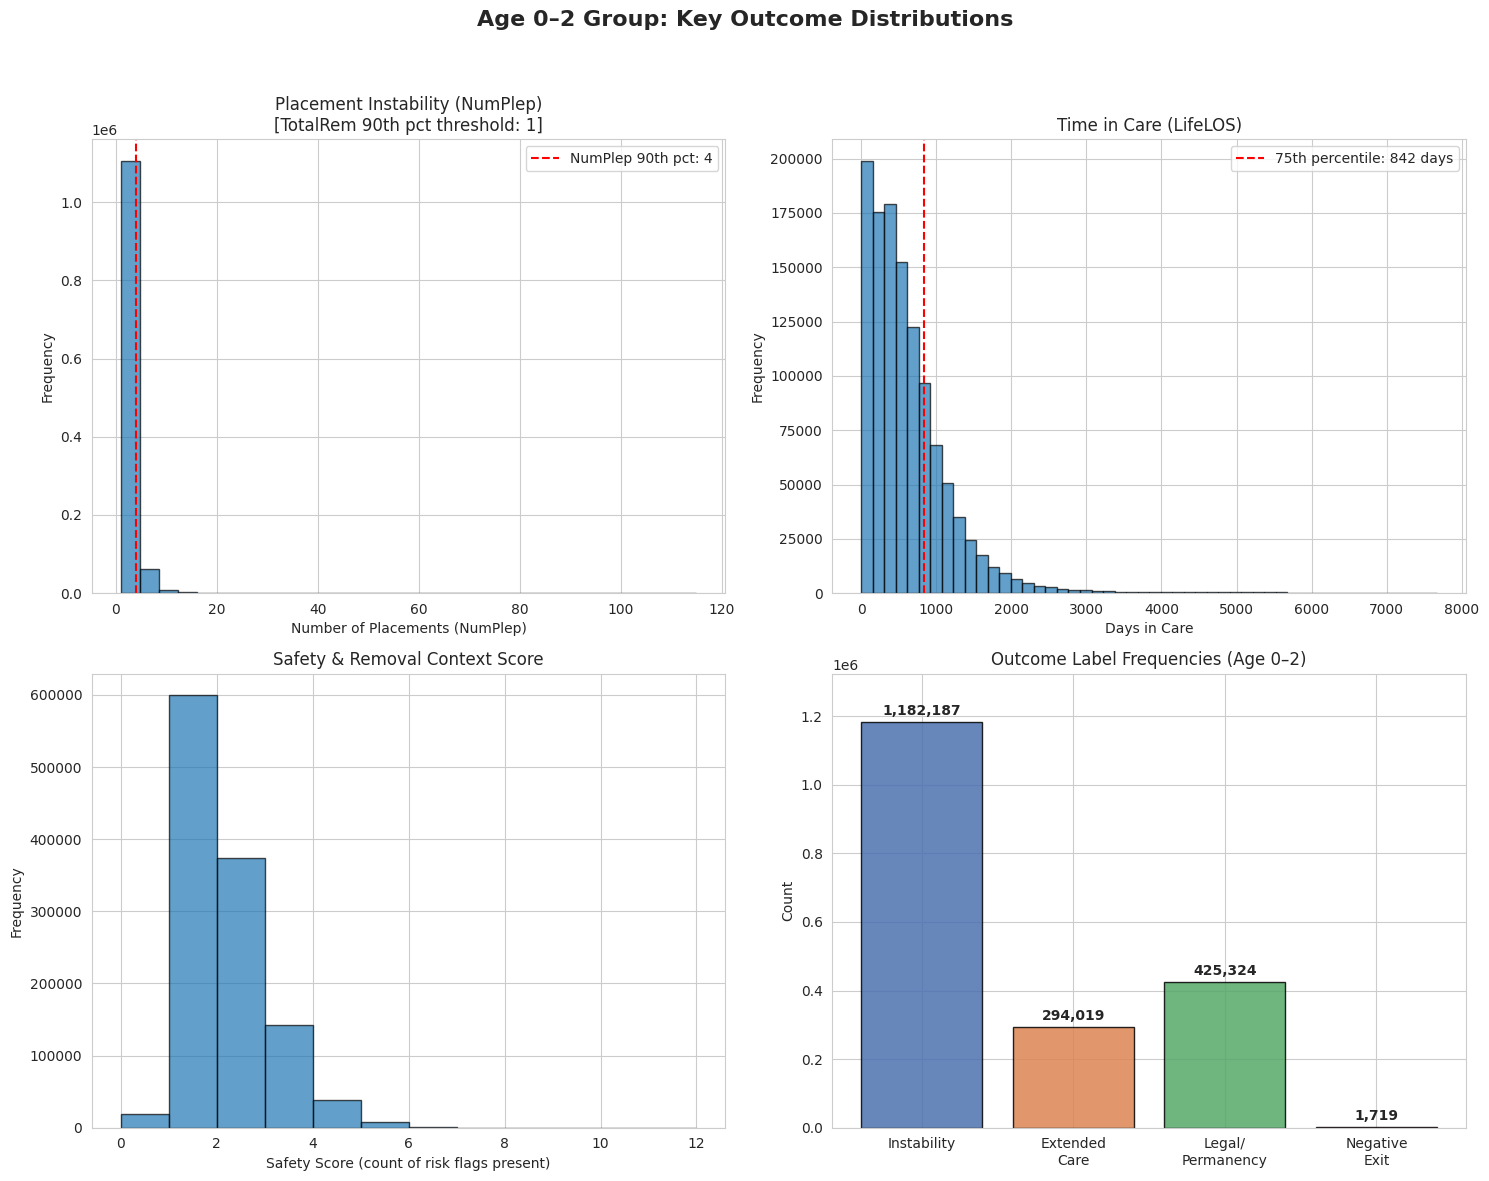


Visualization saved as 'age_0_2_outcomes.png'


In [56]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Age 0–2 Group: Key Outcome Distributions', fontsize=16, fontweight='bold')

outcome_cols_local = [
    'outcome_instability',
    'outcome_extended_care',
    'outcome_legal_permanency',
    'outcome_negative_exit'
]

# ---------------- Plot 1: Placement Instability (NumPlep) ----------------
numplep_data = age_0_2['numplep'].dropna()
axes[0, 0].hist(numplep_data, bins=30, edgecolor='black', alpha=0.7)

numplep_thresh = thresholds_0_2['High Placement Instability']['numplep']
totalrem_thresh = thresholds_0_2['High Placement Instability']['totalrem']

axes[0, 0].axvline(numplep_thresh, color='red', linestyle='--',
                   label=f"NumPlep 90th pct: {numplep_thresh:.0f}")

axes[0, 0].set_xlabel('Number of Placements (NumPlep)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Placement Instability (NumPlep)\n[TotalRem 90th pct threshold: {totalrem_thresh:.0f}]')
axes[0, 0].legend()


# ---------------- Plot 2: Time in Care (LifeLOS) ----------------
lifelos_data = age_0_2['lifelos'].dropna()
axes[0, 1].hist(lifelos_data, bins=50, edgecolor='black', alpha=0.7)

los_thresh = thresholds_0_2['Extended Time in Care']['lifelos']
axes[0, 1].axvline(los_thresh, color='red', linestyle='--',
                   label=f"75th percentile: {los_thresh:.0f} days")

axes[0, 1].set_xlabel('Days in Care')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Time in Care (LifeLOS)')
axes[0, 1].legend()


# ---------------- Plot 3: Safety Score Distribution ----------------
safety_data = age_0_2['safety_score'].dropna()
axes[1, 0].hist(safety_data, bins=np.arange(0, safety_data.max() + 2),
                edgecolor='black', alpha=0.7)

axes[1, 0].set_xlabel('Safety Score (count of risk flags present)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Safety & Removal Context Score')


# ---------------- Plot 4: Outcome Labels ----------------
outcome_counts = age_0_2_labeled[outcome_cols_local].sum()

labels = ['Instability', 'Extended\nCare', 'Legal/\nPermanency', 'Negative\nExit']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = axes[1, 1].bar(labels, outcome_counts.values, color=colors, edgecolor='black', alpha=0.85)


for bar, count in zip(bars, outcome_counts.values):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (outcome_counts.max() * 0.01),
        f'{int(count):,}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Outcome Label Frequencies (Age 0–2)')
axes[1, 1].set_ylim(0, outcome_counts.max() * 1.12)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('age_0_2_outcomes.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'age_0_2_outcomes.png'")

In [57]:
print("TotalRem distribution for age 0-2:")
print(age_0_2['totalrem'].value_counts().sort_index())
print()
print("LifeLOS null rate by TotalRem value:")
for val in [1, 2]:
    subset = age_0_2[age_0_2['totalrem'] == val]
    null_count = subset['lifelos'].isna().sum()
    print(f"  TotalRem={val}: {null_count:,} null LifeLOS ({null_count/len(subset)*100:.1f}%)")

subset_gt2 = age_0_2[age_0_2['totalrem'] > 2]
null_gt2 = subset_gt2['lifelos'].isna().sum()
print(f"  TotalRem>2:  {null_gt2:,} null LifeLOS ({null_gt2/len(subset_gt2)*100:.1f}% of {len(subset_gt2):,} cases)")

subset_null = age_0_2[age_0_2['totalrem'].isna()]
print(f"  TotalRem null: {len(subset_null):,} cases")

TotalRem distribution for age 0-2:
totalrem
1.0     1113008
2.0       64341
3.0        4334
4.0         332
5.0          43
6.0           4
7.0           2
9.0           1
12.0          1
Name: count, dtype: int64

LifeLOS null rate by TotalRem value:
  TotalRem=1: 46 null LifeLOS (0.0%)
  TotalRem=2: 2,421 null LifeLOS (3.8%)
  TotalRem>2:  4,717 null LifeLOS (100.0% of 4,717 cases)
  TotalRem null: 1,050 cases


## Export Processed Data for Age 0-2 Group

In [42]:
# Save the labeled dataset for the 0-2 age group
age_0_2_labeled.to_csv('/content/age_0_2_labeled_data.csv', index=False)
print(f"Saved labeled data for age 0-2 group: {len(age_0_2_labeled):,} records")
print(f"Columns: {list(age_0_2_labeled.columns)}")

Saved labeled data for age 0-2 group: 1,183,116 records
Columns: ['fy', 'version', 'state', 'st', 'repdatyr', 'repdatmo', 'fipscode', 'recnumbr', 'sex', 'amiakn', 'asian', 'blkafram', 'hawaiipi', 'white', 'untodetm', 'hisorgin', 'clindis', 'mr', 'vishear', 'phydis', 'emotdist', 'othermed', 'everadpt', 'ageadopt', 'totalrem', 'numplep', 'manrem', 'phyabuse', 'sexabuse', 'neglect', 'aaparent', 'daparent', 'aachild', 'dachild', 'childis', 'chbehprb', 'prtsdied', 'prtsjail', 'nocope', 'abandmnt', 'relinqsh', 'housing', 'curplset', 'placeout', 'casegoal', 'ctkfamst', 'ctk1yr', 'ctk2yr', 'fosfamst', 'fcctk1yr', 'fcctk2yr', 'rf1amakn', 'rf1asian', 'rf1blkaa', 'rf1nhopi', 'rf1white', 'rf1utod', 'hofcctk1', 'rf2amakn', 'rf2asian', 'rf2blkaa', 'rf2nhopi', 'rf2white', 'rf2utod', 'hofcctk2', 'disreasn', 'ivefc', 'iveaa', 'ivaafdc', 'ivdchsup', 'xixmedcd', 'ssiother', 'noa', 'fcmntpay', 'dob', 'pedrevdt', 'rem1dt', 'remtrndt', 'dlstfcdt', 'latremdt', 'cursetdt', 'dodfcdt', 'dodtrndt', 'tprmomdt', '